In [647]:
#import sys
from pywinauto.application import Application, ProcessNotFoundError
from pywinauto import timings
from tkinter import Tk, filedialog
#import os
#import re
import time

In [648]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [649]:
# Constants
time_sleep = 0.9

In [650]:
# Hide main Tk window
root = Tk()
root.withdraw()

''

In [651]:
# Path to the Windows application executable
app_exe = r"c:\DimDev\DataTools\Read_BIN\ISON_321_20250314\ISON_321.exe"  # TODO: Update this path

In [652]:
# Start the application
app = Application(backend="uia").start(app_exe)

In [653]:
dlg_select_mode = app.window(title=r"Select program type")
dlg_select_mode.wait('visible', timeout=1)
print("Started a new instance of the application.")

<uiawrapper.UIAWrapper - 'Select program type', Dialog, -3500075372380134438>

Started a new instance of the application.


In [654]:
# Try to click the OK button (case-insensitive, anywhere in text)
ok_button = dlg_select_mode.child_window(title="OK", control_type="Button")
ok_button.click_input()
time.sleep(time_sleep)

Case then application start at first and not close after task is done

In [655]:
# try:
#     # Try to connect to a running instance
#     app = Application(backend="uia").connect(path=app_exe)
#     print("Application is already running. Connected to the existing instance.")
#     time.sleep(time_sleep)
# except ProcessNotFoundError:
#     # If not running, start a new instance
#     app = Application(backend="uia").start(app_exe)
#     dlg_select_mode = app.window(title=r"Select program type")
#     dlg_select_mode.wait('visible', timeout=2)
#     print("Started a new instance of the application.")
#     # Try to click the OK button (case-insensitive, anywhere in text)
#     ok_button = dlg_select_mode.child_window(title="OK", control_type="Button")
#     ok_button.click_input()
#     time.sleep(time_sleep)

In [656]:
# Print all controls for debugging
#dlg.print_control_identifiers()

In [657]:
# Print captured title from main window
#print(f"Captured window title: {dlg.window_text()}")

In [658]:
# Select a program type from the ComboBox
#combo = dlg.child_window(auto_id="ProgramTypeSelector.programType", control_type="ComboBox")
#combo.select("ISON Pro")  # or any other item from the list

# Click the OK button
#ok_btn = dlg.child_window(title="OK", control_type="Button")
#ok_btn.click_input()

Open menu item "Convert", pause, select "Convert data to bin file ..."

In [659]:
# Access the main window again if needed
main_win = app.top_window()
print(f"Captured window title: {main_win.window_text()}")
time.sleep(time_sleep)

Captured window title: Inertial Labs ISON v.3.2.1.2


In [660]:
# Print all MenuItem controls in the main window
print("Menu items after clicking Convert:")
for item in main_win.descendants(control_type="MenuItem"):
    print(item.window_text())

Menu items after clicking Convert:
Система
File
Run
Parameters
Plugins
Convert
Options


In [661]:
# Open the "Convert" menu
convert_menu = main_win.child_window(title="Convert", control_type="MenuItem")
print(f"Captured menu item: {convert_menu.window_text()}")
convert_menu.click_input()
time.sleep(time_sleep)  # Pause for 1 second

Captured menu item: Convert


In [662]:
print("Submenu items under Convert:")
for item in convert_menu.descendants(): #control_type="MenuItem"
    print(item.window_text())

Submenu items under Convert:

Report of experiment...
ADC -> Clb data...
Convert to Raw IMU data...
Convert to IMR data...
Convert to DMR data...
Convert log data to bin file...
Combine RAWIMUB and GNSS data...

*.amd -> *.prm...
*.prm -> *.amd...
*.prm -> *.hdr...

*.cdx -> *.txt...
*.cpx -> *.txt...


In [663]:
# Select "Convert data to bin file ..."
convert_log2bin_item = main_win.child_window(title="Convert log data to bin file...", control_type="MenuItem")
convert_log2bin_item.click_input()
time.sleep(time_sleep)  # Wait for dialog to appear

convert_log2bin_item.click_input() open dialog window to select file, how i can see list of files for selecting and then select one?

In [664]:
# Check files in the dialog
listview = main_win.child_window(control_type="List")
for item in listview.descendants(control_type="ListItem"):
    print(item.window_text())

F3003031.flash
INS_Converted.prm


Select *.flash file

In [665]:
# Select the first .flash file from the list
flash_file = [item.window_text() for item in listview.descendants(control_type="ListItem") if item.window_text().endswith(".flash")][0]
flash_file

'F3003031.flash'

In [666]:
# Select a file by its name (replace with your actual file name)
#target_file = item.window_text() # we waiting for only one file in the list
file_item = listview.child_window(title=flash_file, control_type="ListItem")
file_item.click_input()
time.sleep(time_sleep)  

In [667]:
# Find button to open the file
print("All elements in child window:")
Open_file_window = main_win.child_window(title="Open file")
for element in Open_file_window.descendants(title="Відкрити"):
    print(f"{element.element_info.control_type}: {element.window_text()}")
    if element.window_text() == "Відкрити":
        open_btn = element

All elements in child window:
Button: Відкрити


In [668]:
# test button
#open_btn = main_win.child_window(title="Відкрити")
#open_btn.element_info.control_type  # Print the button text
#open_btn.is_enabled()  # Check if the button exists

In [669]:
# Click the Open button (if present)
open_btn = main_win.child_window(title="Відкрити", control_type=open_btn.element_info.control_type)
if open_btn.is_enabled():
    open_btn.click_input()
    time.sleep(time_sleep)  # Wait for the operation to complete
else:
    print("Open button not found or not enabled.")

Select INS.txt

In [670]:
# Check files in the dialog
listview2 = main_win.child_window(control_type="List")
for item in listview2.descendants(control_type="ListItem"):
    print(item.window_text())

GNSS1
INS


In [671]:
# Choose only one file
target_log_file = [item.window_text() for item in listview2.descendants(control_type="ListItem", title="INS")][0]
target_log_file

'INS'

In [672]:
# Select a file by its name (replace with your actual file name)
file_item = listview.child_window(title=target_log_file, control_type="ListItem")
file_item.click_input()
time.sleep(time_sleep)

In [673]:
# Click the Open button (if present)
if open_btn.is_enabled():
    open_btn.click_input()
    time.sleep(time_sleep)  # Wait for the operation to complete
else:
    print("Open button not found or not enabled.")

Waiting for processing log file and click final "OK" button<br>
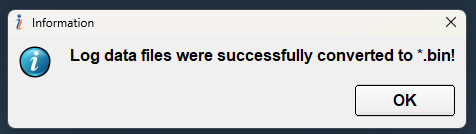

In [674]:
bb = main_win.child_window(title="Information")
bb.window_text() #print_control_identifiers()

'Information'

In [675]:
# Find button to open the file
print("All elements in child window (Information):")
Information_window = main_win.child_window(title="Information")
for element in Information_window.descendants():
    print(f"{element.element_info.control_type}: {element.window_text()}")
    if element.window_text() == "OK":
        ok_btn = element

All elements in child window (Information):
TitleBar: 
MenuBar: Система
MenuItem: Система
Button: Закрити
Image: 
Text: Log data files were successfully converted to *.bin!
Group: 
Button: OK


In [676]:
# Click the button OK
open_btn = main_win.child_window(title="OK", control_type=ok_btn.element_info.control_type)
open_btn.window_text()
open_btn.click_input()
time.sleep(0.5)

'OK'

In [677]:
# Close application
if not Information_window.exists():
   main_win.close()

In [678]:
# Check if the Information window exists and print its text
# if not Information_window.exists():
#     print(Information_window.window_text())
# else:
#     print("Information window not enabled.")